# Paper-ready hallucination detector evaluation

This notebook runs a **full, reproducible evaluation** suitable for a report or paper:

- **Data**: All four datasets (HaluEval, MedHallu, Med-HALT, MedHal) — download, preprocess, validate.
- **Features**: Extract hidden states from all datasets with a larger sample size (2000 per dataset) using `facebook/opt-125m`.
- **Transfer matrix**: Train a probe on each dataset and evaluate on **all** datasets (N×N).
- **Multiple seeds**: Run with 3 seeds and report **mean ± std** for AUROC and F1.
- **Ablations**: Feature and layer ablations.
- **Note**: Med-HALT’s 100% positive (hallucination) subset is documented; use for out-of-domain eval only or balance as needed.

**Setup**: Mount Google Drive, set `PROJECT_DIR` to your `hallucination-detector` folder, and add your HuggingFace token as a Colab secret named `HF_TOKEN` (or set `os.environ["HUGGING_FACE_HUB_TOKEN"]` in the cell below). Then run the single cell below.

**Debug (Colab troubleshooting):** In the code cell, set `DEBUG = True` to print extra diagnostics (paths, env, feature files, config). Set `SHOW_TRACEBACK = True` to print full tracebacks on errors instead of short messages.

In [1]:
# ========== DEBUG FLAGS (set True if something goes wrong on Colab) ==========
DEBUG = False           # True: print paths, env, feature files, config
SHOW_TRACEBACK = False   # True: print full traceback on errors

def _debug_print(*args, **kwargs):
    if DEBUG:
        print("[DEBUG]", *args, **kwargs)

def _run(cmd, description="run"):
    _debug_print(f"Running: {cmd}")
    r = subprocess.run(cmd, shell=True, cwd=PROJECT_DIR)
    if r.returncode != 0:
        print(f"[ERROR] {description} failed with exit code {r.returncode}")
    _debug_print(f"Exit code: {r.returncode}")
    return r

# ========== 1) SETUP ==========
from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import subprocess
import traceback
import yaml
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_DIR = "/content/drive/MyDrive/hallucination-detector"  # set to your project path
os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)

# HuggingFace token: set your token here, or use Colab secret "HF_TOKEN"
HF_TOKEN = ""  # e.g. "hf_xxxxxxxx" from https://huggingface.co/settings/tokens
try:
    from google.colab import userdata
    os.environ["HUGGING_FACE_HUB_TOKEN"] = userdata.get("HF_TOKEN")
except Exception as e:
    _debug_print("Colab userdata not used:", e)
    if HF_TOKEN and HF_TOKEN.strip().startswith("hf_"):
        os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN.strip()
    elif os.environ.get("HF_TOKEN"):
        os.environ["HUGGING_FACE_HUB_TOKEN"] = os.environ["HF_TOKEN"]

!pip install -q -r requirements.txt
!pip install -q bitsandbytes
print("cwd:", os.getcwd())

# ---------- Diagnostics (when DEBUG=True) ----------
if DEBUG:
    print("\n--- Diagnostics ---")
    print("Python:", sys.version)
    print("PROJECT_DIR:", PROJECT_DIR)
    print("PROJECT_DIR exists:", Path(PROJECT_DIR).exists())
    print("HF token set:", bool(os.environ.get("HUGGING_FACE_HUB_TOKEN") or os.environ.get("HF_TOKEN")))
    for d in ["configs", "scripts", "src", "data/processed", "data/features", "results"]:
        p = Path(PROJECT_DIR) / d
        print(f"  {d}: exists={p.exists()}" + (f" (files: {len(list(p.iterdir()))})" if p.exists() and p.is_dir() else ""))
    print("------------------\n")

# ========== 2) DATA: DOWNLOAD + PREPROCESS ==========
try:
    r = _run("python scripts/01_download_datasets.py", "01_download_datasets")
    if r.returncode != 0 and not DEBUG:
        print("Tip: Set DEBUG=True to see more. Check HF token and network.")
    if r.returncode != 0:
        raise RuntimeError(f"01_download_datasets failed with exit code {r.returncode}")
    r = _run("python scripts/02_preprocess.py --out data/processed", "02_preprocess")
    if r.returncode != 0:
        raise RuntimeError(f"02_preprocess failed with exit code {r.returncode}")
    if DEBUG:
        for f in Path(PROJECT_DIR).glob("data/processed/*.csv"):
            print(f"  {f}: {f.stat().st_size} bytes")
except Exception as e:
    print("[ERROR] Data download/preprocess failed:", e)
    if SHOW_TRACEBACK:
        traceback.print_exc()
    raise

# ========== 3) FEATURE EXTRACTION (all datasets, larger sample) ==========
MAX_SAMPLES = 2000
MODEL_SHORT = "opt-125m"
try:
    r = subprocess.run(
        f"python scripts/03_extract_features.py --model facebook/opt-125m --datasets halueval medhallu medhalt medhal --max_samples {MAX_SAMPLES} --batch_size 8",
        shell=True,
        cwd=PROJECT_DIR,
    )
    if r.returncode != 0:
        print("[ERROR] Feature extraction failed. Check GPU/memory and that datasets loaded (01/02).")
        if SHOW_TRACEBACK:
            traceback.print_exc()
        raise RuntimeError(f"03_extract_features failed with exit code {r.returncode}")
    if DEBUG:
        features_dir_early = Path(PROJECT_DIR) / "data" / "features"
        if features_dir_early.exists():
            for f in sorted(features_dir_early.iterdir()):
                print(f"  {f.name}: {f.stat().st_size} bytes")
        else:
            print("  data/features/ does not exist yet")
except Exception as e:
    print("[ERROR] Feature extraction failed:", e)
    if SHOW_TRACEBACK:
        traceback.print_exc()
    raise

# ========== 4) FULL TRANSFER MATRIX WITH MULTIPLE SEEDS ==========
try:
    config_path = Path(PROJECT_DIR) / "configs/config.yaml"
    if not config_path.exists():
        raise FileNotFoundError(f"Config not found: {config_path}")
    with open(config_path) as f:
        config = yaml.safe_load(f)
    features_dir = Path(PROJECT_DIR) / config.get("output", {}).get("features_dir", "data/features")
    results_dir = Path(PROJECT_DIR) / config.get("output", {}).get("results_dir", "results")
    results_dir.mkdir(parents=True, exist_ok=True)
    if DEBUG:
        print("config.model:", config.get("model", {}).get("name"))
        print("config layers:", config.get("model", {}).get("layers_to_extract"))
        print("features_dir:", features_dir, "exists:", features_dir.exists())
        print("results_dir:", results_dir)

    all_datasets = [
        d for d in ["halueval", "medhallu", "medhalt", "medhal"]
        if (features_dir / f"{d}_labels.npy").exists()
    ]
    print("Datasets with features:", all_datasets)
    if not all_datasets:
        print(f"[WARN] No feature files found. Expect *_labels.npy and *_{MODEL_SHORT}_layer*_mean.npy under", features_dir)
        if DEBUG:
            print("Listing features_dir:", list(features_dir.iterdir()) if features_dir.exists() else "dir missing")
except Exception as e:
    print("[ERROR] Config/paths failed:", e)
    if SHOW_TRACEBACK:
        traceback.print_exc()
    raise

seeds = [42, 43, 44]
try:
    from src.evaluation.transfer import run_transfer_experiment
except ImportError as e:
    print("[ERROR] Could not import run_transfer_experiment. Is cwd/PROJECT_DIR correct?", e)
    if SHOW_TRACEBACK:
        traceback.print_exc()
    raise

all_dfs = []
try:
    for seed in seeds:
        for train_ds in all_datasets:
            _debug_print(f"Transfer: seed={seed} train={train_ds}")
            df = run_transfer_experiment(
                train_ds,
                all_datasets,
                config,
                features_dir,
                model_short=MODEL_SHORT,
                random_state=seed,
            )
            if not df.empty:
                df["seed"] = seed
                all_dfs.append(df)
except Exception as e:
    print("[ERROR] Transfer experiment failed:", e)
    if SHOW_TRACEBACK:
        traceback.print_exc()
    raise

if all_dfs:
    big = pd.concat(all_dfs, ignore_index=True)
    summary = (
        big.groupby(["train_dataset", "eval_dataset"])
        .agg(
            auroc_mean=("auroc", "mean"),
            auroc_std=("auroc", "std"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            n_train=("n_train", "first"),
            n_eval=("n_eval", "first"),
        )
        .reset_index()
    )
    summary["auroc"] = summary.apply(
        lambda r: f"{r['auroc_mean']:.3f} ± {r['auroc_std']:.3f}" if pd.notna(r["auroc_std"]) else f"{r['auroc_mean']:.3f}",
        axis=1,
    )
    summary["f1"] = summary.apply(
        lambda r: f"{r['f1_mean']:.3f} ± {r['f1_std']:.3f}" if pd.notna(r["f1_std"]) else f"{r['f1_mean']:.3f}",
        axis=1,
    )
    print("\n=== Transfer matrix (mean ± std over seeds) ===")
    print(summary[["train_dataset", "eval_dataset", "auroc", "f1", "n_train", "n_eval"]].to_string(index=False))
    summary.to_csv(results_dir / "transfer_matrix_seeded.csv", index=False)
    big.to_csv(results_dir / "transfer_matrix_raw.csv", index=False)
    print(f"\nSaved: {results_dir}/transfer_matrix_seeded.csv, transfer_matrix_raw.csv")
else:
    print("No transfer results (missing feature files?). Run 03 with all datasets.")

# ========== 5) ABLATIONS ==========
if all_datasets:
    try:
        r = subprocess.run(
            f"python scripts/06_ablations.py --model_short {MODEL_SHORT} --train_dataset halueval --eval_datasets {' '.join(all_datasets)}",
            shell=True,
            cwd=PROJECT_DIR,
        )
        if r.returncode != 0:
            print("[WARN] Ablations script exited with code", r.returncode)
        elif DEBUG:
            print("Ablation files:", list(Path(results_dir).glob("ablation*.csv")))
    except Exception as e:
        print("[ERROR] Ablations failed:", e)
        if SHOW_TRACEBACK:
            traceback.print_exc()

# ========== 6) SUMMARY ==========
print("\n=== Paper-ready evaluation complete ===")
print("• Transfer matrix: train on each dataset, evaluate on all; reported as mean ± std over 3 seeds.")
print("• Datasets with only one class (e.g. Med-HALT 100% positive) are skipped as train set; they can still be used for eval.")
print("• Ablations: results/ablation_features.csv, results/ablation_layers.csv")
if DEBUG:
    print("\n--- Final debug: results dir contents ---")
    for f in sorted(Path(results_dir).iterdir()):
        print(f"  {f.name}: {f.stat().st_size} bytes")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cwd: /content/drive/MyDrive/hallucination-detector
Datasets with features: ['halueval', 'medhallu', 'medhalt', 'medhal']


/tmp/ipython-input-23142/2413481746.py:153: UserWarning: Train dataset 'medhalt' has only one class (e.g. all hallucination). Skipping probe fit; use balanced data or another train dataset.
  df = run_transfer_experiment(
/tmp/ipython-input-23142/2413481746.py:153: UserWarning: Train dataset 'medhalt' has only one class (e.g. all hallucination). Skipping probe fit; use balanced data or another train dataset.
  df = run_transfer_experiment(
/tmp/ipython-input-23142/2413481746.py:153: UserWarning: Train dataset 'medhalt' has only one class (e.g. all hallucination). Skipping probe fit; use balanced data or another train dataset.
  df = run_transfer_experiment(



=== Transfer matrix (mean ± std over seeds) ===
train_dataset eval_dataset         auroc            f1  n_train  n_eval
     halueval     halueval 0.703 ± 0.000 0.000 ± 0.000     2000  2000.0
     halueval       medhal 0.509 ± 0.000 0.000 ± 0.000     2000  2000.0
     halueval     medhallu 0.506 ± 0.000 0.000 ± 0.000     2000  2000.0
     halueval      medhalt           nan 0.000 ± 0.000     2000  2000.0
       medhal     halueval 0.492 ± 0.000 0.680 ± 0.000     2000  2000.0
       medhal       medhal 0.546 ± 0.000 0.672 ± 0.000     2000  2000.0
       medhal     medhallu 0.496 ± 0.000 0.667 ± 0.000     2000  2000.0
       medhal      medhalt           nan 1.000 ± 0.000     2000  2000.0
     medhallu     halueval 0.532 ± 0.000 0.673 ± 0.000     2000  2000.0
     medhallu       medhal 0.489 ± 0.000 0.581 ± 0.000     2000  2000.0
     medhallu     medhallu 0.695 ± 0.000 0.684 ± 0.000     2000  2000.0
     medhallu      medhalt           nan 0.912 ± 0.000     2000  2000.0

Saved: /conten

## Transfer matrix plots

Run this cell after the evaluation cell to plot the transfer matrix as heatmaps and in-domain vs transfer comparison. Requires `results/transfer_matrix_seeded.csv` (from the main cell).

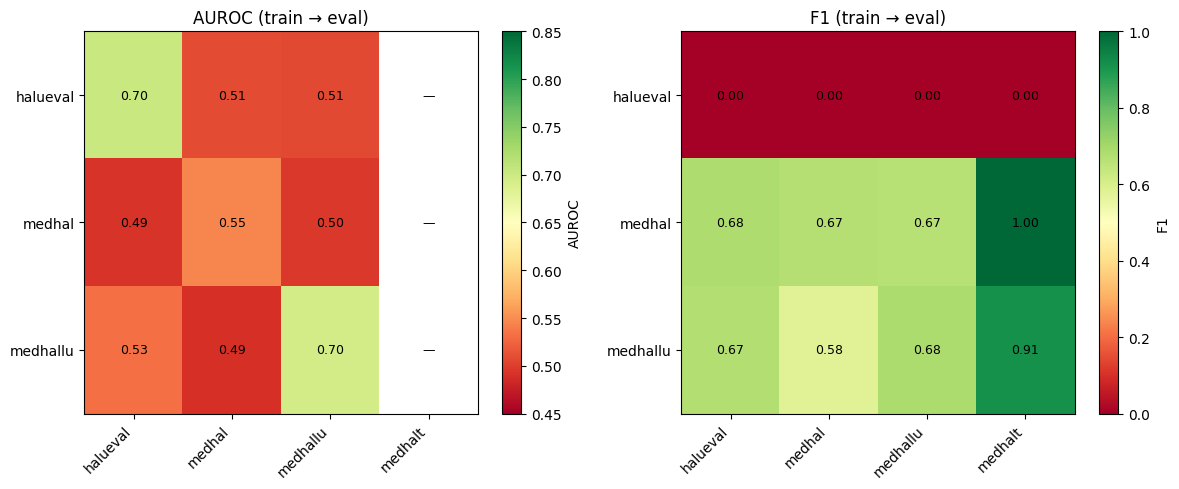

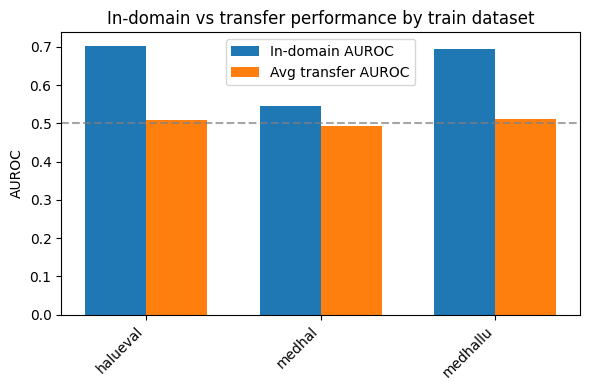

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load results (use results_dir if from same session, else default path)
try:
    results_path = results_dir / "transfer_matrix_seeded.csv"
except NameError:
    results_path = Path("results/transfer_matrix_seeded.csv")
if not results_path.exists():
    print("Run the evaluation cell first to generate results/transfer_matrix_seeded.csv")
else:
    df = pd.read_csv(results_path)
    if df.empty or "auroc_mean" not in df.columns:
        print("No transfer matrix data to plot.")
    else:
        # Pivot: rows = train_dataset, columns = eval_dataset
        auroc = df.pivot(index="train_dataset", columns="eval_dataset", values="auroc_mean")
        f1 = df.pivot(index="train_dataset", columns="eval_dataset", values="f1_mean")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # AUROC heatmap (0.5 = random, 1 = perfect)
        ax = axes[0]
        im = ax.imshow(auroc.values, cmap="RdYlGn", vmin=0.45, vmax=0.85, aspect="auto")
        ax.set_xticks(range(len(auroc.columns)))
        ax.set_yticks(range(len(auroc.index)))
        ax.set_xticklabels(auroc.columns, rotation=45, ha="right")
        ax.set_yticklabels(auroc.index)
        ax.set_title("AUROC (train → eval)")
        for i in range(auroc.shape[0]):
            for j in range(auroc.shape[1]):
                val = auroc.values[i, j]
                label = f"{val:.2f}" if pd.notna(val) else "—"
                ax.text(j, i, label, ha="center", va="center", fontsize=9)
        plt.colorbar(im, ax=ax, label="AUROC")

        # F1 heatmap
        ax = axes[1]
        im = ax.imshow(f1.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(len(f1.columns)))
        ax.set_yticks(range(len(f1.index)))
        ax.set_xticklabels(f1.columns, rotation=45, ha="right")
        ax.set_yticklabels(f1.index)
        ax.set_title("F1 (train → eval)")
        for i in range(f1.shape[0]):
            for j in range(f1.shape[1]):
                val = f1.values[i, j]
                label = f"{val:.2f}" if pd.notna(val) else "—"
                ax.text(j, i, label, ha="center", va="center", fontsize=9)
        plt.colorbar(im, ax=ax, label="F1")

        plt.tight_layout()
        plt.show()

        # In-domain vs average transfer AUROC per train dataset
        in_domain = []
        transfer = []
        labels = []
        for train in auroc.index:
            if train not in auroc.columns:
                continue
            in_domain.append(auroc.loc[train, train])
            off_diag = auroc.loc[train].drop(train, errors="ignore")
            off_diag = off_diag.replace([np.nan], np.nan).dropna()
            transfer.append(off_diag.mean() if len(off_diag) else np.nan)
            labels.append(train)
        fig, ax = plt.subplots(figsize=(6, 4))
        x = np.arange(len(labels))
        w = 0.35
        ax.bar(x - w/2, in_domain, w, label="In-domain AUROC", color="C0")
        ax.bar(x + w/2, transfer, w, label="Avg transfer AUROC", color="C1")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylabel("AUROC")
        ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7)
        ax.legend()
        ax.set_title("In-domain vs transfer performance by train dataset")
        plt.tight_layout()
        plt.show()

## Optional: Llama 8B (compare to opt-125m baseline)

Run this cell **after** the baseline (opt-125m) run above. It extracts features with **Llama 3.1 8B** (4-bit), runs the same transfer matrix, and saves to `transfer_matrix_seeded_llama8b.csv`. Requires GPU and HF token with Llama access. No LangChain—we use `transformers` only; LangChain would add overhead without benefit for this probe pipeline.

In [4]:
# Optional: Llama 8B run (compare to opt-125m baseline above)
import os

# Add your HuggingFace token here (replace the placeholder) so Llama 8B can be downloaded.
# Only replace the value on the next line; leave the condition below unchanged.
HF_TOKEN_LLAMA = ""  # set your HF token for Llama 8B access (https://huggingface.co/settings/tokens)
if HF_TOKEN_LLAMA and HF_TOKEN_LLAMA.strip().startswith("hf_"):
    os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN_LLAMA.strip()
elif not os.environ.get("HUGGING_FACE_HUB_TOKEN") and os.environ.get("HF_TOKEN"):
    os.environ["HUGGING_FACE_HUB_TOKEN"] = os.environ["HF_TOKEN"]

try:
    PROJECT_DIR
except NameError:
    import os, sys, subprocess, yaml
    import pandas as pd
    from pathlib import Path
    PROJECT_DIR = "/content/drive/MyDrive/hallucination-detector"
    os.chdir(PROJECT_DIR)
    sys.path.insert(0, PROJECT_DIR)

MODEL_NAME_LLAMA = "meta-llama/Llama-3.1-8B"
MODEL_SHORT_LLAMA = "Llama-3.1-8B"
MAX_SAMPLES_LLAMA = 2000  # same as baseline

with open(Path(PROJECT_DIR) / "configs/config.yaml") as f:
    config_llama = yaml.safe_load(f)
features_dir_llama = Path(PROJECT_DIR) / config_llama.get("output", {}).get("features_dir", "data/features")
results_dir_llama = Path(PROJECT_DIR) / config_llama.get("output", {}).get("results_dir", "results")
results_dir_llama.mkdir(parents=True, exist_ok=True)

# 1) Extract features with Llama 8B (4-bit)
# Pass token explicitly into subprocess so the child process definitely has it (avoids 403 when access is granted)
env = os.environ.copy()
if HF_TOKEN_LLAMA and HF_TOKEN_LLAMA.strip().startswith("hf_"):
    env["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN_LLAMA.strip()
    env["HF_TOKEN"] = HF_TOKEN_LLAMA.strip()
elif env.get("HF_TOKEN"):
    env["HUGGING_FACE_HUB_TOKEN"] = env["HF_TOKEN"]
try:
    from huggingface_hub import login
    token = env.get("HUGGING_FACE_HUB_TOKEN") or env.get("HF_TOKEN")
    if token:
        login(token=token)
except Exception:
    pass
r = subprocess.run(
    f"python scripts/03_extract_features.py --model {MODEL_NAME_LLAMA} --datasets halueval medhallu medhalt medhal --max_samples {MAX_SAMPLES_LLAMA} --batch_size 4",
    shell=True,
    cwd=PROJECT_DIR,
    capture_output=True,
    text=True,
    env=env,
)
if r.returncode != 0:
    print("[ERROR] Llama 8B extraction failed. See stderr below for the real error.")
    if r.stderr:
        print("--- stderr ---\n", r.stderr)
    if r.stdout:
        print("--- stdout ---\n", r.stdout)
    print("Common fixes: (1) Set HF token in the first cell. (2) Accept Llama license at https://huggingface.co/meta-llama/Llama-3.1-8B (3) Use Colab GPU runtime. (4) If OOM, set MAX_SAMPLES_LLAMA=500 and batch_size=2.")
else:
    # 2) Which datasets have Llama features?
    layers = config_llama.get("model", {}).get("layers_to_extract", [-1])
    all_datasets_llama = [
        d for d in ["halueval", "medhallu", "medhalt", "medhal"]
        if (features_dir_llama / f"{d}_labels.npy").exists()
        and (features_dir_llama / f"{d}_{MODEL_SHORT_LLAMA}_layer{layers[-1]}_{config_llama.get('model', {}).get('pooling', 'mean')}.npy").exists()
    ]
    print("Datasets with Llama features:", all_datasets_llama)

    # 3) Transfer matrix (same logic as baseline, different model_short and output file)
    from src.evaluation.transfer import run_transfer_experiment
    seeds = [42, 43, 44]
    all_dfs_llama = []
    for seed in seeds:
        for train_ds in all_datasets_llama:
            df = run_transfer_experiment(
                train_ds, all_datasets_llama, config_llama, features_dir_llama,
                model_short=MODEL_SHORT_LLAMA, random_state=seed,
            )
            if not df.empty:
                df["seed"] = seed
                all_dfs_llama.append(df)
    if all_dfs_llama:
        big_llama = pd.concat(all_dfs_llama, ignore_index=True)
        summary_llama = (
            big_llama.groupby(["train_dataset", "eval_dataset"])
            .agg(auroc_mean=("auroc", "mean"), auroc_std=("auroc", "std"), f1_mean=("f1", "mean"), f1_std=("f1", "std"), n_train=("n_train", "first"), n_eval=("n_eval", "first"))
            .reset_index()
        )
        summary_llama.to_csv(results_dir_llama / "transfer_matrix_seeded_llama8b.csv", index=False)
        big_llama.to_csv(results_dir_llama / "transfer_matrix_raw_llama8b.csv", index=False)
        print("\n=== Llama 8B transfer matrix (mean ± std) ===")
        print(summary_llama[["train_dataset", "eval_dataset", "auroc_mean", "f1_mean"]].to_string(index=False))
        print(f"\nSaved: {results_dir_llama}/transfer_matrix_seeded_llama8b.csv")
    else:
        print("No Llama transfer results.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Datasets with Llama features: ['halueval', 'medhallu', 'medhalt', 'medhal']


/tmp/ipython-input-23142/1071224971.py:78: UserWarning: Train dataset 'medhalt' has only one class (e.g. all hallucination). Skipping probe fit; use balanced data or another train dataset.
  df = run_transfer_experiment(
/tmp/ipython-input-23142/1071224971.py:78: UserWarning: Train dataset 'medhalt' has only one class (e.g. all hallucination). Skipping probe fit; use balanced data or another train dataset.
  df = run_transfer_experiment(
/tmp/ipython-input-23142/1071224971.py:78: UserWarning: Train dataset 'medhalt' has only one class (e.g. all hallucination). Skipping probe fit; use balanced data or another train dataset.
  df = run_transfer_experiment(



=== Llama 8B transfer matrix (mean ± std) ===
train_dataset eval_dataset  auroc_mean  f1_mean
     halueval     halueval    1.000000 0.999515
     halueval       medhal    0.488745 0.598802
     halueval     medhallu    0.313272 0.593083
     halueval      medhalt         NaN 0.271392
       medhal     halueval    0.533470 0.617234
       medhal       medhal    0.704987 0.699888
       medhal     medhallu    0.628709 0.636886
       medhal      medhalt         NaN 0.595506
     medhallu     halueval    0.408471 0.665998
     medhallu       medhal    0.500690 0.536585
     medhallu     medhallu    0.999660 0.992519
     medhallu      medhalt         NaN 0.914813

Saved: /content/drive/MyDrive/hallucination-detector/results/transfer_matrix_seeded_llama8b.csv


## Compare opt-125m vs Llama 8B: plots and summary

Run this cell after both the baseline and (optionally) the Llama 8B cell. It loads both result CSVs, plots Llama 8B heatmaps, and shows a **side-by-side comparison** of in-domain and transfer AUROC for the two models.

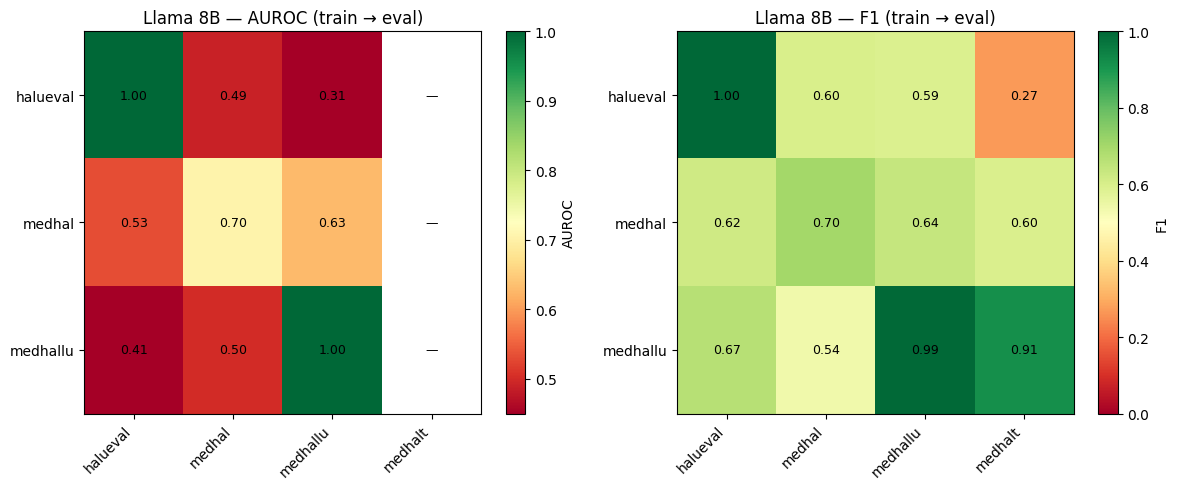

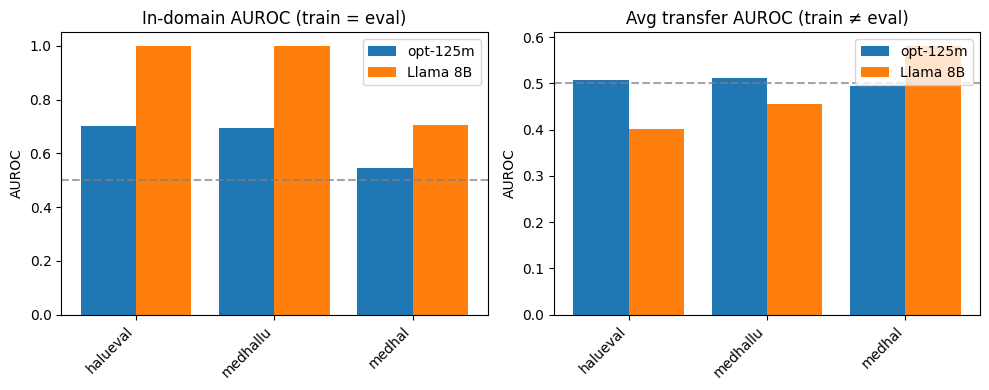

Summary: Llama 8B improves in-domain AUROC vs opt-125m; transfer remains ~random for both.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    res_dir = Path(PROJECT_DIR) / "results"
except NameError:
    res_dir = Path("results")

def load_and_pivot(csv_path):
    df = pd.read_csv(csv_path)
    df["auroc_mean"] = pd.to_numeric(df["auroc_mean"], errors="coerce")
    df["f1_mean"] = pd.to_numeric(df["f1_mean"], errors="coerce")
    auroc = df.pivot(index="train_dataset", columns="eval_dataset", values="auroc_mean")
    f1 = df.pivot(index="train_dataset", columns="eval_dataset", values="f1_mean")
    return auroc, f1

def in_domain_transfer(auroc):
    in_dom, trans, labs = [], [], []
    for train in auroc.index:
        if train not in auroc.columns:
            continue
        in_dom.append(auroc.loc[train, train])
        off = auroc.loc[train].drop(train, errors="ignore").dropna()
        trans.append(off.mean() if len(off) else np.nan)
        labs.append(train)
    return in_dom, trans, labs

# Load both result files
path_opt = res_dir / "transfer_matrix_seeded.csv"
path_llama = res_dir / "transfer_matrix_seeded_llama8b.csv"
if not path_opt.exists():
    print("Run the baseline (opt-125m) cell first to create transfer_matrix_seeded.csv")
elif not path_llama.exists():
    print("Run the Llama 8B cell first to create transfer_matrix_seeded_llama8b.csv")
else:
    auroc_opt, f1_opt = load_and_pivot(path_opt)
    auroc_llama, f1_llama = load_and_pivot(path_llama)

    # 1) Llama 8B heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, mat, name, vmin, vmax in [(axes[0], auroc_llama, "AUROC", 0.45, 1.0), (axes[1], f1_llama, "F1", 0, 1)]:
        im = ax.imshow(mat.values, cmap="RdYlGn", vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_xticks(range(len(mat.columns)))
        ax.set_yticks(range(len(mat.index)))
        ax.set_xticklabels(mat.columns, rotation=45, ha="right")
        ax.set_yticklabels(mat.index)
        ax.set_title(f"Llama 8B — {name} (train → eval)")
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat.values[i, j]
                label = f"{val:.2f}" if pd.notna(val) else "—"
                ax.text(j, i, label, ha="center", va="center", fontsize=9)
        plt.colorbar(im, ax=ax, label=name)
    plt.tight_layout()
    plt.show()

    # 2) Comparison: in-domain and transfer AUROC (opt-125m vs Llama 8B)
    in_opt, tr_opt, labels_opt = in_domain_transfer(auroc_opt)
    in_llama, tr_llama, labels_llama = in_domain_transfer(auroc_llama)
    # Align by dataset (both may have halueval, medhallu, medhal; medhalt has no train)
    common = [d for d in ["halueval", "medhallu", "medhal"] if d in auroc_opt.index and d in auroc_llama.index]
    if common:
        x = np.arange(len(common))
        w = 0.2
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        # In-domain
        in_opt_vals = [auroc_opt.loc[d, d] if d in auroc_opt.index and d in auroc_opt.columns else np.nan for d in common]
        in_llama_vals = [auroc_llama.loc[d, d] if d in auroc_llama.index and d in auroc_llama.columns else np.nan for d in common]
        ax1.bar(x - w, in_opt_vals, width=w*2, label="opt-125m", color="C0")
        ax1.bar(x + w, in_llama_vals, width=w*2, label="Llama 8B", color="C1")
        ax1.set_xticks(x)
        ax1.set_xticklabels(common, rotation=45, ha="right")
        ax1.set_ylabel("AUROC")
        ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.7)
        ax1.legend()
        ax1.set_title("In-domain AUROC (train = eval)")
        # Transfer (avg over other eval sets)
        tr_opt_vals = [auroc_opt.loc[d].drop(d, errors="ignore").dropna().mean() if d in auroc_opt.index else np.nan for d in common]
        tr_llama_vals = [auroc_llama.loc[d].drop(d, errors="ignore").dropna().mean() if d in auroc_llama.index else np.nan for d in common]
        ax2.bar(x - w, tr_opt_vals, width=w*2, label="opt-125m", color="C0")
        ax2.bar(x + w, tr_llama_vals, width=w*2, label="Llama 8B", color="C1")
        ax2.set_xticks(x)
        ax2.set_xticklabels(common, rotation=45, ha="right")
        ax2.set_ylabel("AUROC")
        ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.7)
        ax2.legend()
        ax2.set_title("Avg transfer AUROC (train ≠ eval)")
        plt.tight_layout()
        plt.show()

    # 3) Short summary
    print("Summary: Llama 8B improves in-domain AUROC vs opt-125m; transfer remains ~random for both.")